In [9]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.DataFrame(columns = ["Model", "Dataset", "Visited nodes", "Applied prunes"])

for file in os.listdir("./results"):
    file_name = file.split(".txt")[0]
    model, dataset = file_name.split("_")
    if model == "BerryFinderNoPrune":
        continue
    with open(f"./results/{file}", "r") as f:
        visited_nodes = int(f.readline().strip().split(": ")[1])
        f.readline()  # Skip credible sugroups
        f.readline()  # Skip selected subgroups
        if model != "QFinder":
            applied_prunes = int(f.readline().strip().split(": ")[1])
        else:
            applied_prunes = pd.NA
    df.loc[len(df)] = [model, dataset, visited_nodes, applied_prunes]

In [11]:
df.head()

,Model,Dataset,Visited nodes,Applied prunes
0,SDMapStar,Cardio,1284,0
1,ExCover,HealthyAging,589,530
2,BSD,StudentSuccess,61976489,15594587
3,BSD,Mushrooms,1443113,87068
4,BerryFinder,connect4,2384049,47004


In [12]:
df["Model"] = df["Model"].replace({
    "QFinder": "Q-Finder",
    "SDMapStar": "SDMap*",
    "BerryFinderNoPrune": "BerryFinder (no pruning)"
})

In [13]:
algorithm_order = order = [ "BSD", "SDMap*", "Q-Finder","BerryFinder", "ExCover" ,"BerryFinder (no pruning)"]

df = df.sort_values(by="Model", key=lambda x: x.map({model: i for i, model in enumerate(algorithm_order)}))

In [14]:
# Rename Datasets for better readability
df["Dataset"] = df["Dataset"].replace({
    "StudentSuccess": "Student Success",
    "Car": "Car Evaluation",
    "connect4": "Connect-4",
    "HealthyAging": "Healthy Aging"
})

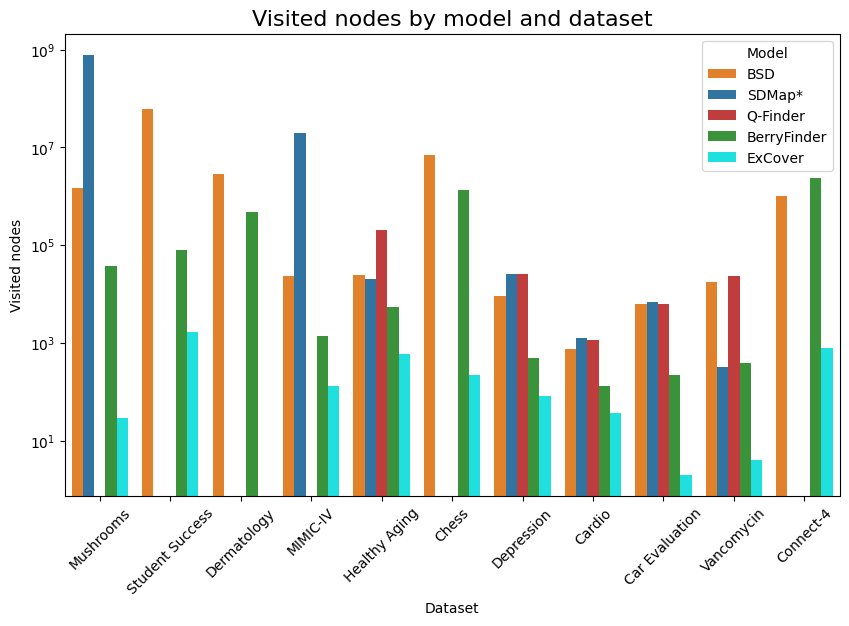

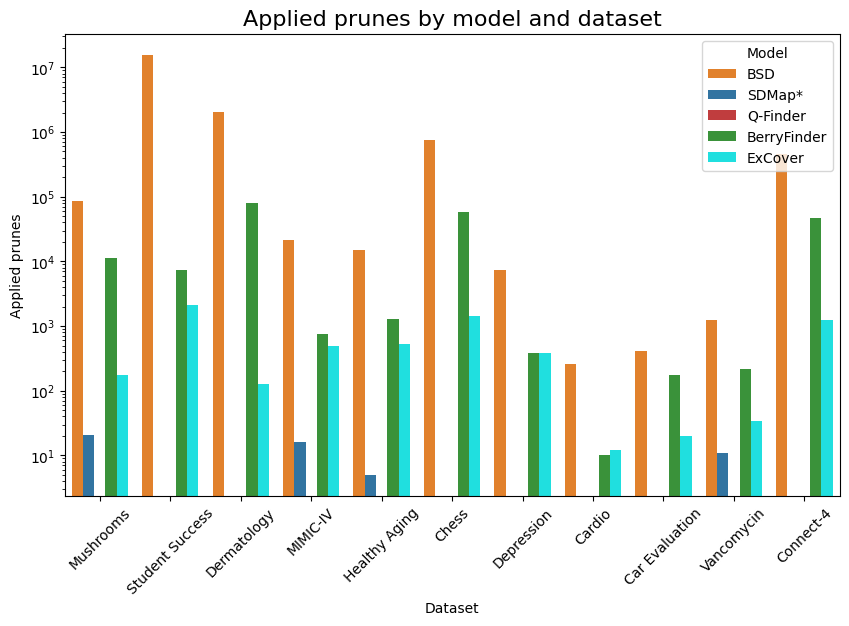

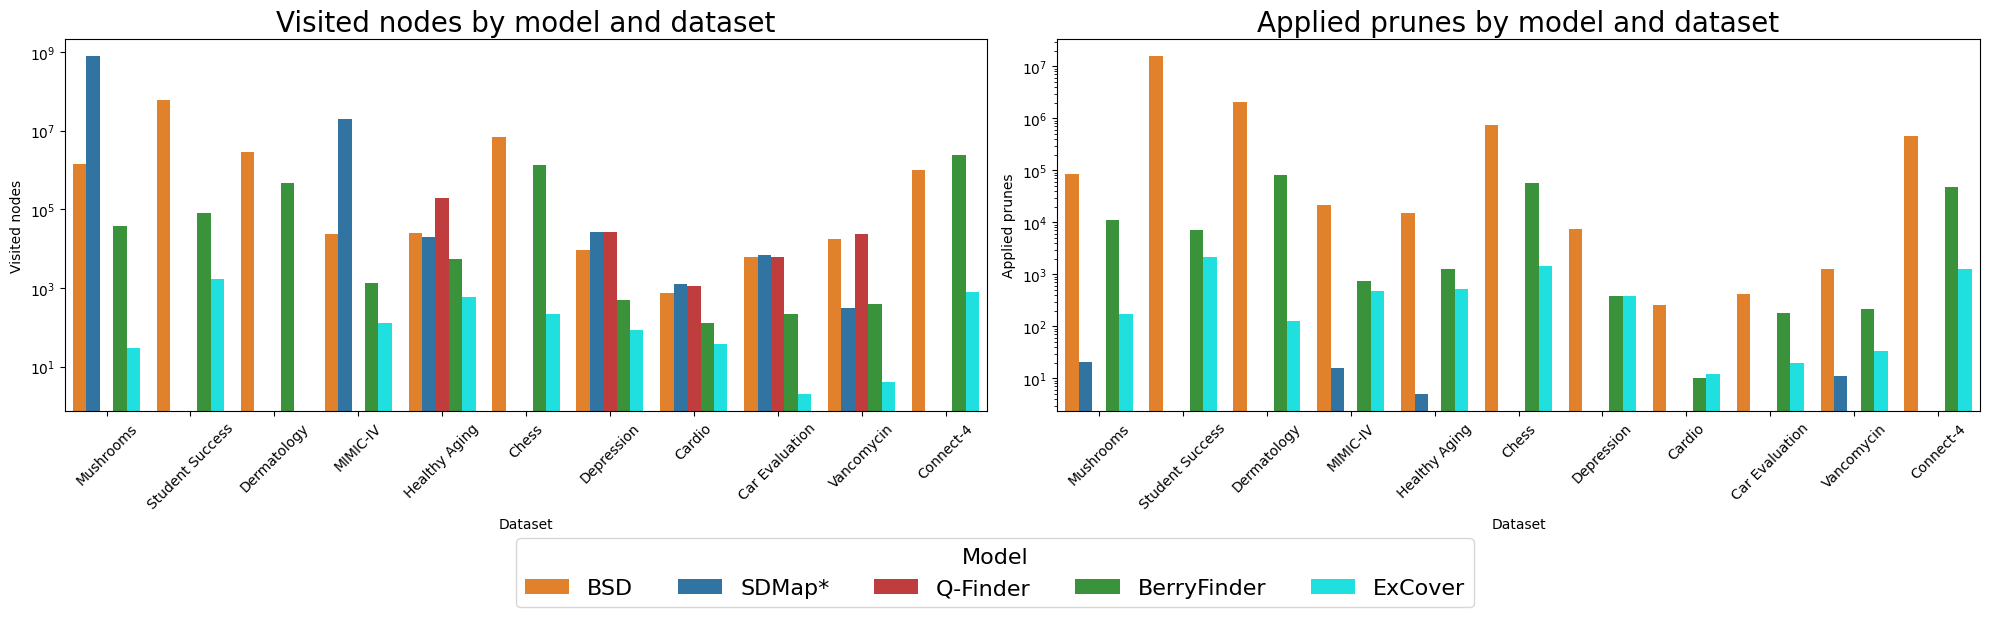

In [21]:
palette = {
    "Q-Finder": "tab:red",
    "BerryFinder": "tab:green",
    "SDMap*": "tab:blue",
    "BSD" : "tab:orange",
    "BerryFinder (no pruning)": "tab:purple",
    "ExCover": "cyan"
}


fontsize = 16

fig = plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Dataset", y="Visited nodes", hue="Model", palette=palette)
plt.yscale("log")
plt.title("Visited nodes by model and dataset", fontsize=fontsize)
# Tilt x labels
plt.xticks(rotation=45)

fig = plt.figure(figsize=(10, 6))
sns.barplot(data=df[df["Model"] != "QFinder"], x="Dataset", y="Applied prunes", hue="Model", palette=palette)
plt.yscale("log")
plt.title("Applied prunes by model and dataset", fontsize=fontsize)
# Tilt x labels
plt.xticks(rotation=45)
plt.show()



# Join both plots. Use common legend
fontsize = 20

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=df, x="Dataset", y="Visited nodes", hue="Model", ax=axes[0], palette=palette)
axes[0].set_yscale("log")
axes[0].set_title("Visited nodes by model and dataset", fontsize=fontsize)
# Tilt x labels
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df[df["Model"] != "QFinder"], x="Dataset", y="Applied prunes", hue="Model", ax=axes[1], palette=palette)
axes[1].set_yscale("log")
axes[1].set_title("Applied prunes by model and dataset", fontsize=fontsize)
# Tilt x labels
axes[1].tick_params(axis='x', rotation=45)

# Get legend entries from the first plot (it contains all the models)
handles, labels = axes[0].get_legend_handles_labels()

# Remove the individual legends
axes[0].get_legend().remove()
axes[1].get_legend().remove()

# Add a single common legend at the bottom center of the figure
fig.legend(
    handles,
    labels,
    title="Model",
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.04),
    fontsize=16,
    title_fontsize=16,
)

# Leave space at the bottom for the legend
fig.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

plt.show()

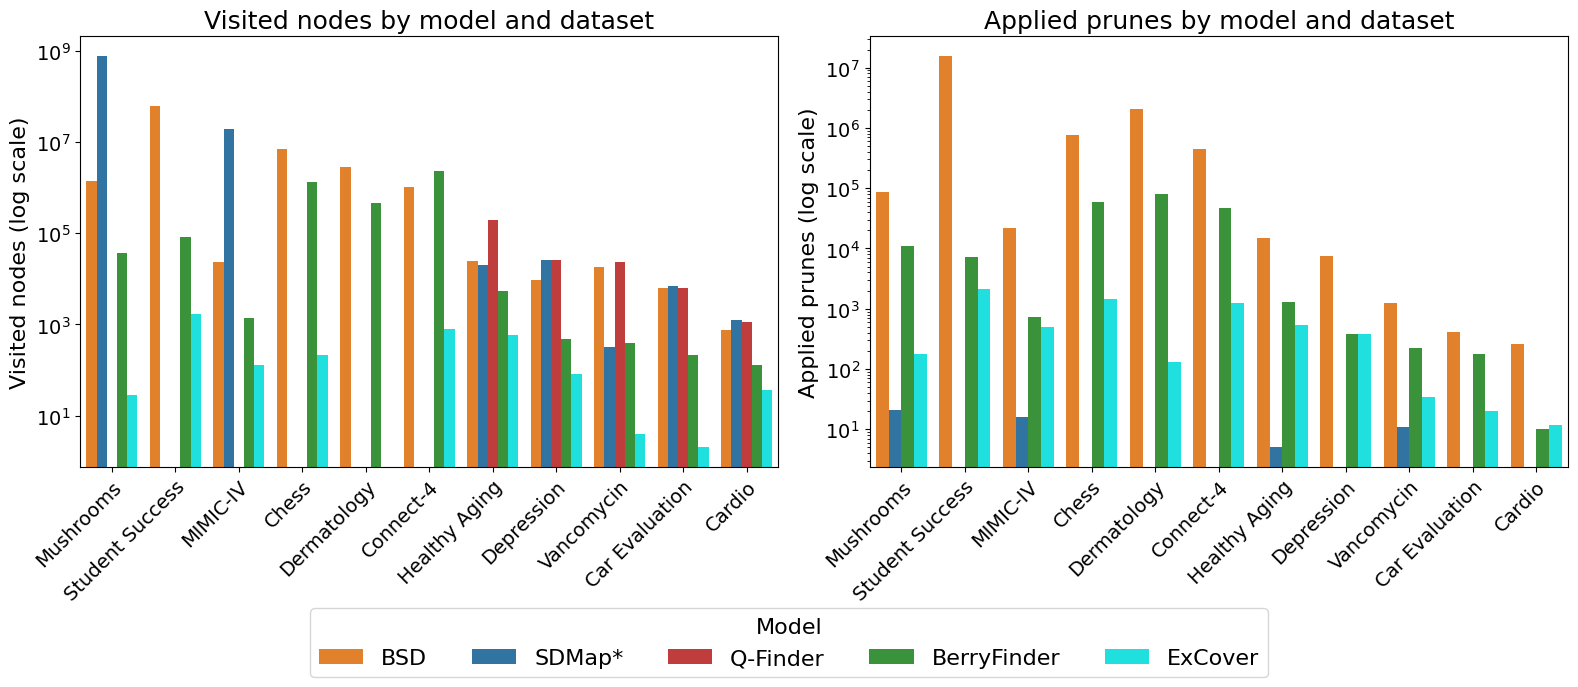

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global font sizes (applied consistently to every text element)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
})

# Same order in both plots so positions and colors are comparable
model_order = ["BSD", "SDMap*", "Q-Finder", "BerryFinder", "ExCover"]
dataset_order = (
    df.groupby("Dataset")["Visited nodes"].max().sort_values(ascending=False).index
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(
    data=df, x="Dataset", y="Visited nodes", hue="Model",
    order=dataset_order, hue_order=model_order,
    ax=axes[0], palette=palette,
)
axes[0].set_yscale("log")
axes[0].set_title("Visited nodes by model and dataset")
axes[0].set_xlabel("")
axes[0].set_ylabel("Visited nodes (log scale)")

# Q-Finder has no pruning data, so it is excluded from the second plot
sns.barplot(
    data=df[df["Model"] != "QFinder"], x="Dataset", y="Applied prunes", hue="Model",
    order=dataset_order, hue_order=[m for m in model_order if m != "Q-Finder"],
    ax=axes[1], palette=palette,
)
axes[1].set_yscale("log")
axes[1].set_title("Applied prunes by model and dataset")
axes[1].set_xlabel("")
axes[1].set_ylabel("Applied prunes (log scale)")

# Tilt x labels and anchor them to the right so they do not overlap
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Common legend: take handles from the first plot, remove the individual legends
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.legend(
    handles, labels,
    title="Model",
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 0.0),
)

fig.tight_layout(rect=[0, 0.09, 1, 1])
plt.show()

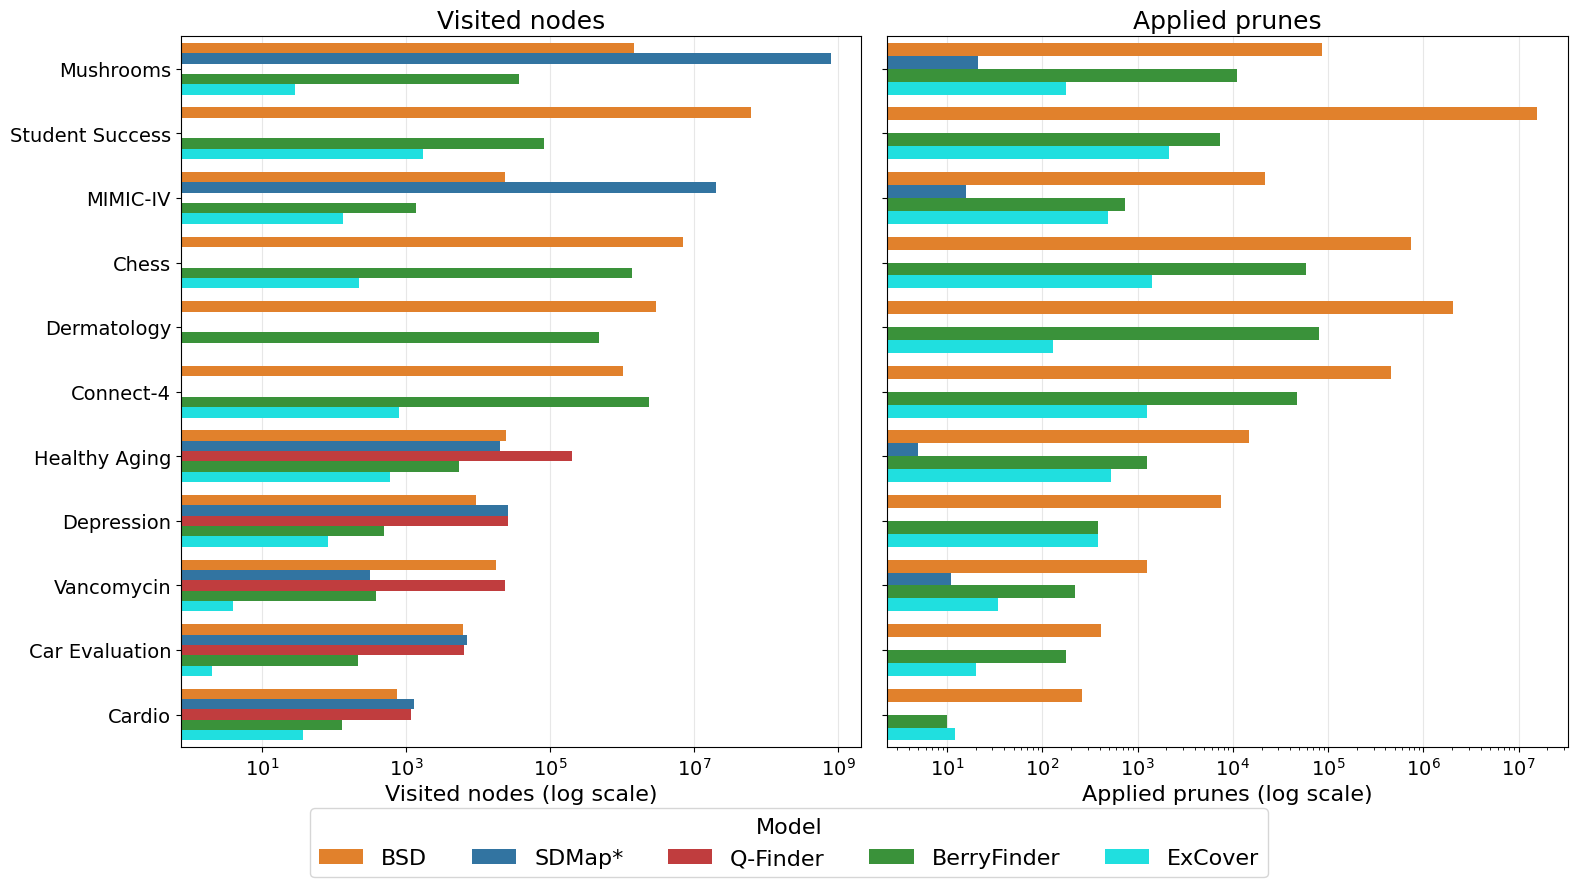

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global font sizes
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
})

# Same order in both plots so positions and colors are comparable
model_order = ["BSD", "SDMap*", "Q-Finder", "BerryFinder", "ExCover"]
dataset_order = (
    df.groupby("Dataset")["Visited nodes"].max().sort_values(ascending=False).index
)

# Horizontal bars, datasets share the y axis (labels only on the left)
fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharey=True)

sns.barplot(
    data=df, y="Dataset", x="Visited nodes", hue="Model",
    order=dataset_order, hue_order=model_order,
    orient="h", ax=axes[0], palette=palette,
)
axes[0].set_xscale("log")
axes[0].set_title("Visited nodes")
axes[0].set_xlabel("Visited nodes (log scale)")
axes[0].set_ylabel("")

# Q-Finder has no pruning data, so it is excluded from the second plot
sns.barplot(
    data=df[df["Model"] != "Q-Finder"], y="Dataset", x="Applied prunes", hue="Model",
    order=dataset_order, hue_order=[m for m in model_order if m != "Q-Finder"],
    orient="h", ax=axes[1], palette=palette,
)
axes[1].set_xscale("log")
axes[1].set_title("Applied prunes")
axes[1].set_xlabel("Applied prunes (log scale)")
axes[1].set_ylabel("")

# Light vertical grid helps to read values on a log scale
for ax in axes:
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

# Common legend at the bottom center
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.legend(
    handles, labels,
    title="Model",
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 0.0),
)

fig.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

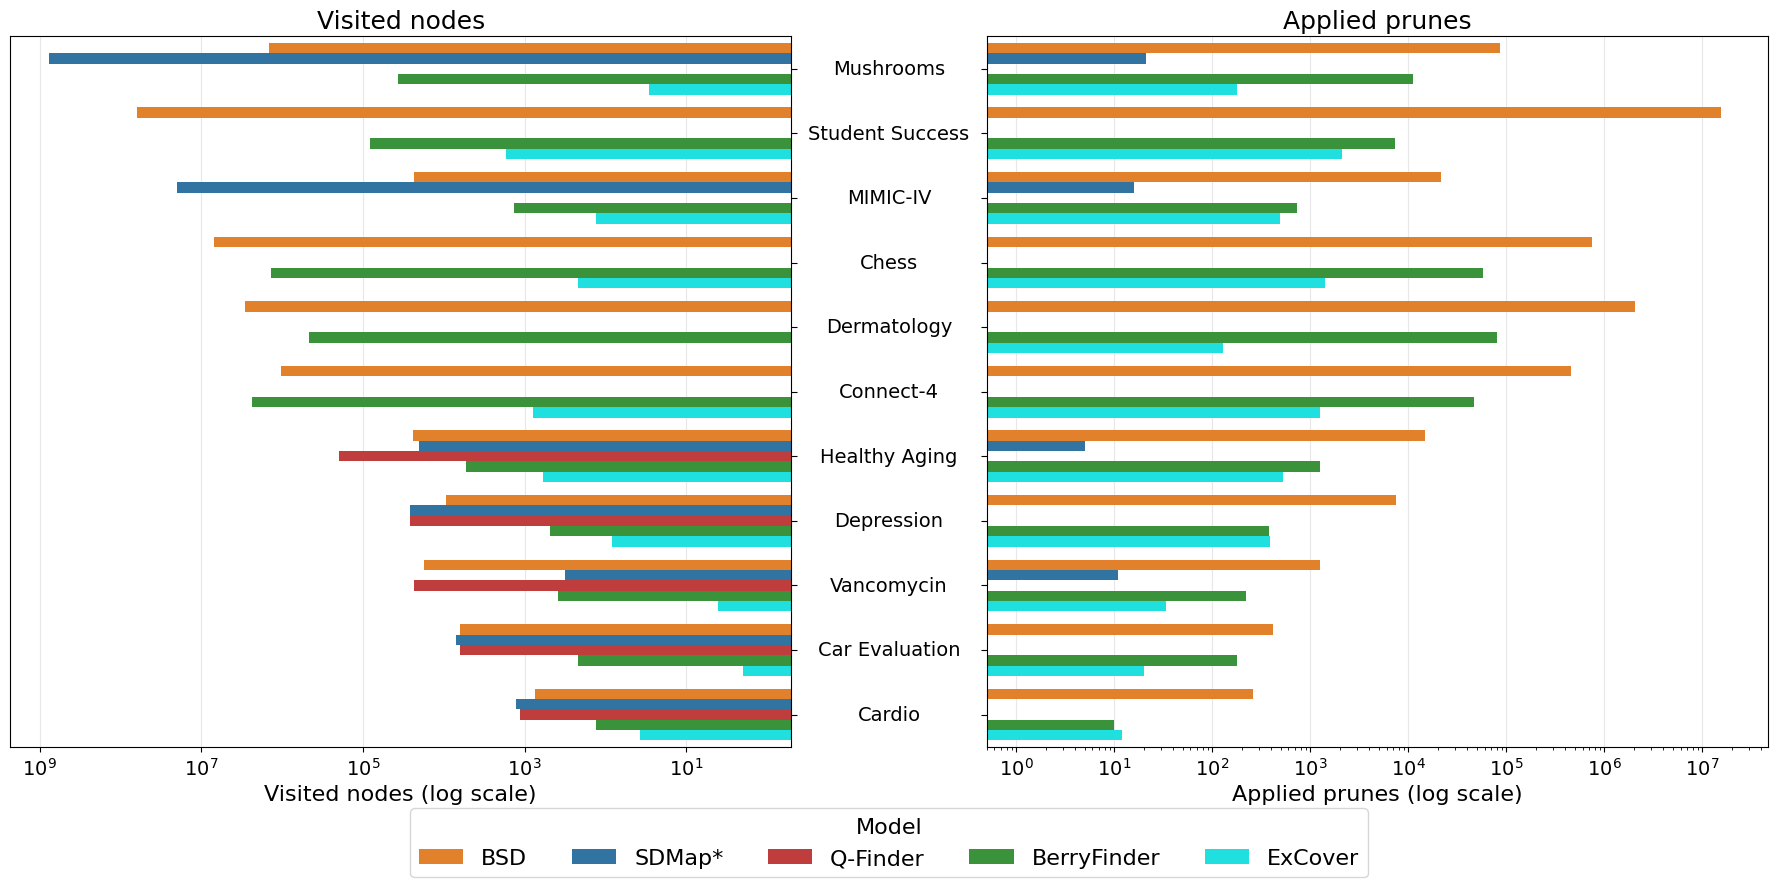

In [35]:
import matplotlib.pyplot as plt
import matplotlib.transforms
import seaborn as sns

# Global font sizes (applied consistently to every text element)
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
    "legend.title_fontsize": 16,
})

# Same order in both panels so rows and colors are aligned
model_order = ["BSD", "SDMap*", "Q-Finder", "BerryFinder", "ExCover"]
dataset_order = (
    df.groupby("Dataset")["Visited nodes"].max().sort_values(ascending=False).index
)

# Butterfly chart: left panel grows to the left, right panel grows to the right
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharey=True)

# ---------------------------------------------------------------------------
# Left panel: visited nodes (bars grow to the left)
# ---------------------------------------------------------------------------
sns.barplot(
    data=df, y="Dataset", x="Visited nodes", hue="Model",
    order=dataset_order, hue_order=model_order,
    orient="h", ax=axes[0], palette=palette,
)
axes[0].set_xscale("log")
axes[0].set_xlim(df["Visited nodes"].max() * 3, 0.5)  # inverted limits: bars grow to the left
axes[0].set_title("Visited nodes")
axes[0].set_xlabel("Visited nodes (log scale)")
axes[0].set_ylabel("")

# ---------------------------------------------------------------------------
# Right panel: applied prunes (bars grow to the right)
# ---------------------------------------------------------------------------
# hue_order keeps Q-Finder (empty) so bars are perfectly aligned with the left panel
sns.barplot(
    data=df, y="Dataset", x="Applied prunes", hue="Model",
    order=dataset_order, hue_order=model_order,
    orient="h", ax=axes[1], palette=palette,
)
axes[1].set_xscale("log")
axes[1].set_xlim(0.5, df["Applied prunes"].max() * 3)
axes[1].set_title("Applied prunes")
axes[1].set_xlabel("Applied prunes (log scale)")
axes[1].set_ylabel("")

# ---------------------------------------------------------------------------
# Ticks: keep the marks on both sides of the center, hide the default labels
# (dataset names are drawn manually, centered between the panels)
# ---------------------------------------------------------------------------
axes[0].yaxis.tick_right()
axes[0].tick_params(axis="y", right=True, labelright=False, length=4)
axes[1].tick_params(axis="y", left=True, labelleft=False, length=4)

# Light vertical grid helps to read values on a log scale
for ax in axes:
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)

# ---------------------------------------------------------------------------
# Common legend at the bottom center of the figure
# ---------------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.legend(
    handles, labels,
    title="Model",
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 0.0),
)

# ---------------------------------------------------------------------------
# Layout: must be finished BEFORE computing the center of the gap
# ---------------------------------------------------------------------------
fig.tight_layout(rect=[0, 0.07, 1, 1])
# Leave room between the panels for the dataset names
fig.subplots_adjust(wspace=0.25)

# ---------------------------------------------------------------------------
# Dataset names centered between both panels
# ---------------------------------------------------------------------------
# Horizontal center of the gap between both panels (figure coordinates)
pos_left = axes[0].get_position()
pos_right = axes[1].get_position()
x_center = (pos_left.x1 + pos_right.x0) / 2

# x in figure coordinates, y in data coordinates of the left panel
transform = matplotlib.transforms.blended_transform_factory(fig.transFigure, axes[0].transData)

for i, name in enumerate(dataset_order):
    axes[0].text(
        x_center, i, name,
        transform=transform,
        ha="center", va="center",
        fontsize=plt.rcParams["ytick.labelsize"],
    )

plt.show()
# To save without cutting the legend:
# fig.savefig("plot.png", bbox_inches="tight", dpi=300)